# Titanic Dataset – Exploratory Data Analysis

## Project Context

This notebook presents a rigorous exploratory data analysis (EDA) of the Titanic dataset from Kaggle.

The objective is not merely descriptive exploration, but the systematic identification of:

- Structural patterns in the data
- Data quality issues
- Missingness mechanisms
- Variable interactions
- Feature engineering opportunities
- Modeling risks

This EDA is designed as the foundation of a full Machine Learning pipeline.

---

## Problem Definition

We aim to predict passenger survival (`Survived`) using structured passenger information.

- **Task type:** Binary classification  
- **Target variable:** `Survived` (0 = Did not survive, 1 = Survived)

---

## Methodological Standard

This analysis follows professional data science practices:

- Reproducible structure
- Quantified decisions
- Explicit handling of missing data
- Clear distinction between variable types
- Identification of interaction effects
- Strategic connection to modeling

Each analytical block concludes with actionable insights.

---

## Guiding Principle

If an analysis does not produce a modeling decision, it is not included.

The goal is to reduce uncertainty and prepare a robust preprocessing strategy,
not to produce decorative visualizations.

---

## Expected Outcomes

By the end of this notebook, we will have:

1. Identified dominant predictors.
2. Diagnosed missingness mechanisms.
3. Detected non-linear relationships.
4. Proposed justified feature transformations.
5. Defined a preprocessing roadmap for modeling.

This document serves as a professional reference implementation of EDA.

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
FIG_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [35]:
titanic_path = f"{DATA_DIR}/titanic_data.csv"
titanic_df = pd.read_csv(titanic_path)

print(f"Dataset shape: {titanic_df.shape}")
titanic_df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Titanic EDA – Professional Standard

## Objective
Perform a rigorous exploratory data analysis to understand the Titanic dataset
and prepare justified preprocessing decisions for a future classification model.

## Target
`Survived` — Binary classification:
- 0 → Did not survive
- 1 → Survived

## Guiding Questions

1. Is survival strongly associated with Sex?
2. Does Pclass influence survival probability?
3. How does Age relate to survival, and how severe is missingness?
4. Is Fare skewed and does it require transformation?
5. Do family-related variables (SibSp, Parch) impact survival?
6. Is Cabin missingness informative?
7. Are there high-cardinality variables that may cause noise?
8. What risks could affect modeling (imbalance, missing data bias, leakage)?

In [36]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


As we can see, we have some real columns:

- Fare
- Age

Integer columns (possible categorical variables or ids):

- PassengerId
- Pclass
- SibSp
- Parch

Float columns:

- Age
- Fare

String columns (They may have categorical values or text with useful information for extraction):

- Name
- Sex
- Ticket
- Cabin
- Embarked

The target column is: 

- Survived


In [37]:
missing_ratio = (
    titanic_df.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name="missing_ratio")
)

missing_ratio

,missing_ratio
Cabin,0.771044
Age,0.198653
Embarked,0.002245
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


`cabin` is the variable with the greatest quantity of null values. This can suggest that this column can be droped in the feature selection step.

In the case of columns as Age and Embarked, they must be studied. It is possible to complete or discard rows.

In [38]:
cardinality = (
    titanic_df.nunique()
    .sort_values(ascending=False)
    .to_frame(name="unique_values")
)

cardinality.head(12)

,unique_values
PassengerId,891
Name,891
Ticket,681
Fare,248
Cabin,147
Age,88
SibSp,7
Parch,7
Embarked,3
Pclass,3


## Preliminary Structural Decisions

Based on missingness and cardinality analysis:

### Cabin
- Will not be used directly due to 77% missing values.
- A new feature `deck` (first letter) will be extracted.
- A binary variable `has_cabin` will be created.

### Ticket
- High cardinality (681 unique values).
- Will be excluded from modeling unless future analysis shows strong signal.

### Name
- Not usable directly (891 unique values).
- Titles will be extracted (Mr, Mrs, Miss, Master, etc.).
- This feature may capture age, gender, and social status effects.

These transformations aim to preserve useful information while reducing noise and overfitting risk.

# Analyzing the Target Variable

In [39]:
titanic_df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: xlabel='Survived'>

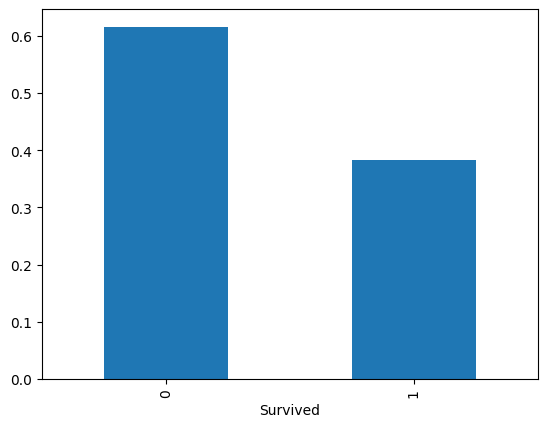

In [40]:
titanic_df["Survived"].value_counts(normalize=True).plot(kind="bar")

61.6% did not survived

38.4% survived

This shows that:

- The target is not perfecly balanced but there is not extremely imbalanced
- A naive model (predict always 0) will get a 61.6% of accuracy

In [41]:
pd.crosstab(titanic_df["Sex"], titanic_df["Survived"], normalize="index")

Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


This is a Big difference. 

- The `Sex` variable is probably the most predictive one of the Dataset
- This supports the hypotheses of having titles (Mr/ Mrs/ Miss) can be relevant
- This suggests a strong structural bias ("Women and children first")

In [42]:
pd.crosstab(titanic_df["Pclass"], titanic_df["Survived"], normalize="index")

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


In this case the Pclass is ordinal. That means that the probability of survival is bigger if the class is less.

## Target Analysis – Key Findings

### Class Imbalance

- 61.6% of passengers did not survive.
- 38.4% survived.

The dataset is moderately imbalanced. Accuracy alone would be misleading, so
future modeling should consider metrics such as F1-score or ROC-AUC.

---

### Survival by Sex

- Female survival rate: 74.2%
- Male survival rate: 18.9%

Sex is extremely predictive. The difference suggests strong structural bias
("women and children first"). Extracting titles from `Name` is justified.

---

### Survival by Pclass

- Pclass 1 survival rate: 62.9%
- Pclass 2 survival rate: 47.3%
- Pclass 3 survival rate: 24.2%

There is a clear monotonic relationship between socioeconomic status and survival.
`Pclass` should be treated as an ordinal feature.

---

### Strategic Implications

1. Sex is likely the strongest predictor.
2. Socioeconomic status (Pclass) has a major effect.
3. Interaction effects (Sex × Pclass) should be analyzed.
4. Feature engineering from `Name` is justified.

# Analyzing Sex x Pclass for surviving

In [43]:
pd.crosstab(
    [titanic_df["Sex"], titanic_df["Pclass"]],
    titanic_df["Survived"],
    normalize="index"
)

Survived              0         1
Sex    Pclass                    
female 1       0.031915  0.968085
       2       0.078947  0.921053
       3       0.500000  0.500000
male   1       0.631148  0.368852
       2       0.842593  0.157407
       3       0.864553  0.135447

## Interaction Analysis – Sex × Pclass

### Female Survival Rates

- 1st class: 96.8%
- 2nd class: 92.1%
- 3rd class: 50.0%

Even among women, socioeconomic status significantly affects survival.
Class 3 women had dramatically lower survival rates.

---

### Male Survival Rates

- 1st class: 36.9%
- 2nd class: 15.7%
- 3rd class: 13.5%

Male passengers had substantially lower survival rates overall,
but class still plays a role.

---

### Structural Insight

There is a strong interaction between Sex and Pclass.

The survival advantage of women is amplified in higher classes.
Socioeconomic status significantly modifies survival probability.

This confirms:

1. Interaction effects are important.
2. Extracting structured information from `Name` (titles) is justified.
3. Tree-based models may capture these interactions effectively.

In [44]:
titanic_df["family_size"] = (
    titanic_df["SibSp"] +
    titanic_df["Parch"] +
    1
)

titanic_df["is_alone"] = (
    titanic_df["family_size"] == 1
).astype(int)

In [45]:
pd.crosstab(
    titanic_df["family_size"],
    titanic_df["Survived"],
    normalize="index"
)

Survived,0,1
family_size,,
1,0.696462,0.303538
2,0.447205,0.552795
3,0.421569,0.578431
4,0.275862,0.724138
5,0.800000,0.200000
6,0.863636,0.136364
7,0.666667,0.333333
8,1.000000,0.000000
11,1.000000,0.000000


In [46]:
pd.crosstab(
    titanic_df["is_alone"],
    titanic_df["Survived"],
    normalize="index"
)

Survived,0,1
is_alone,,
0,0.494350,0.505650
1,0.696462,0.303538


## Family Structure Analysis – Key Findings

### Family Size

Survival rates show a non-linear relationship:

- Alone (size = 1): 30.3%
- Small families (2–4): highest survival (55–72%)
- Large families (5+): significantly lower survival

This suggests:
- Protective effect of small family groups.
- Logistical disadvantage for very large families.
- Non-linear behavior that may require transformation.

---

### Is Alone

Passengers traveling alone had a survival rate of 30.3%,
compared to 50.6% for those traveling with family.

Being alone appears to be a strong negative survival factor.

---

### Strategic Implications

1. `family_size` should replace raw `SibSp` and `Parch`.
2. `is_alone` is a strong candidate feature.
3. Non-linear relationships should be considered during modeling.

In [47]:
pd.cut(titanic_df["Age"], bins=[0, 12, 18, 35, 60, 100]).value_counts()

Age
(18, 35]     358
(35, 60]     195
(12, 18]      70
(0, 12]       69
(60, 100]     22
Name: count, dtype: int64

In [48]:
age_bins = pd.cut(
    titanic_df["Age"],
    bins=[0, 12, 18, 35, 60, 100]
)

pd.crosstab(
    age_bins,
    titanic_df["Survived"],
    normalize="index"
)

Survived,0,1
Age,,
"(0, 12]",0.420290,0.579710
"(12, 18]",0.571429,0.428571
"(18, 35]",0.617318,0.382682
"(35, 60]",0.600000,0.400000
"(60, 100]",0.772727,0.227273


## Age and Survival – Key Findings

### Age Distribution

Most passengers were between 18 and 35 years old.
Children and elderly passengers represent a smaller proportion.

---

### Survival by Age Group

- Children (0–12): 57.9%
- Teenagers (12–18): 42.9%
- Adults (18–60): ~38–40%
- Elderly (60+): 22.7%

Children show significantly higher survival rates,
while elderly passengers had the lowest survival probability.

---

### Structural Insight

Age affects survival, but the effect appears non-linear.
Children benefit from a survival advantage,
while older passengers are at higher risk.

However, age effects may be confounded by sex.
Further interaction analysis is required.

In [49]:
pd.crosstab(
    [age_bins, titanic_df["Sex"]],
    titanic_df["Survived"],
    normalize="index"
)

Survived                 0         1
Age       Sex                       
(0, 12]   female  0.406250  0.593750
          male    0.432432  0.567568
(12, 18]  female  0.250000  0.750000
          male    0.911765  0.088235
(18, 35]  female  0.216667  0.783333
          male    0.819328  0.180672
(35, 60]  female  0.228571  0.771429
          male    0.808000  0.192000
(60, 100] female  0.000000  1.000000
          male    0.894737  0.105263

## Interaction Analysis – Age × Sex

### Children (0–12)

- Female survival: 59.4%
- Male survival: 56.8%

Sex has little effect among children.
The survival advantage appears age-driven rather than gender-driven.

---

### Teenagers (12–18)

- Female survival: 75.0%
- Male survival: 8.8%

From adolescence onward, sex becomes the dominant factor.

---

### Adults (18–60)

Female survival remains very high (~77–78%).
Male survival remains very low (~18–19%).

In adult groups, sex overwhelmingly determines survival probability.

---

### Elderly (60+)

Results must be interpreted cautiously due to small sample size.
However, elderly males show very low survival rates.

---

### Structural Insight

1. The effect of age is strongly conditioned by sex.
2. Sex becomes the dominant predictor after childhood.
3. Interaction terms (Age × Sex) may improve linear models.
4. Title extraction is strongly justified.

In [50]:
titanic_df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: >

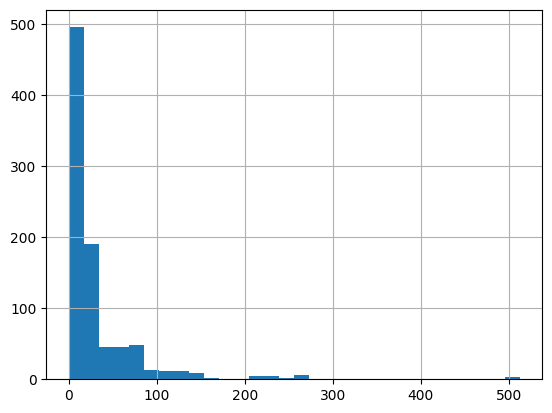

In [51]:
titanic_df["Fare"].hist(bins=30)

<Axes: >

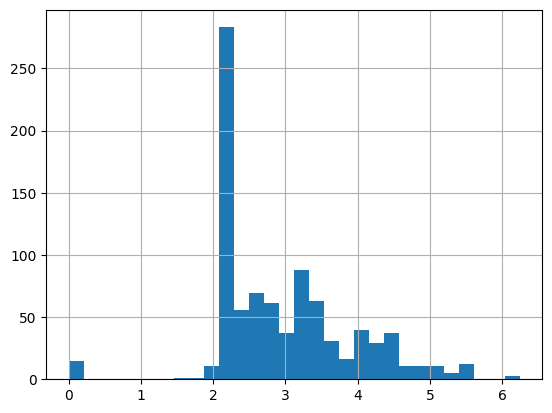

In [52]:
np.log1p(titanic_df["Fare"]).hist(bins=30)

## Fare – Distribution Analysis

### Summary Statistics

- Mean: 32.20
- Median: 14.45
- Standard deviation: 49.69
- Maximum: 512.33

The mean is more than double the median, indicating strong positive skewness.
The maximum fare is significantly larger than the 75th percentile (31.00),
suggesting the presence of extreme outliers.

---

### Structural Insight

Fare is highly right-skewed and likely correlated with socioeconomic status.

Implications:
1. A log-transformation may stabilize variance.
2. Outliers should be examined before modeling.
3. Fare may partially capture the same signal as Pclass.

In [53]:
titanic_df.groupby("Pclass")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


## Fare by Pclass – Structural Analysis

There is a clear separation of fare distribution across passenger classes:

- Class 1: mean = 84.15
- Class 2: mean = 20.66
- Class 3: mean = 13.68

Fare strongly reflects socioeconomic status and is highly correlated with Pclass.

---

### Strategic Implications

1. Fare and Pclass likely contain overlapping information.
2. Fare may capture within-class variability.
3. Collinearity should be evaluated during modeling.
4. Both variables will be retained initially.

In [54]:
pd.crosstab(
    titanic_df["Age"].isna(),
    titanic_df["Pclass"],
    normalize="columns"
)

Pclass,1,2,3
Age,,,
False,0.861111,0.940217,0.723014
True,0.138889,0.059783,0.276986


In [55]:
pd.crosstab(
    titanic_df["Age"].isna(),
    titanic_df["Sex"],
    normalize="columns"
)

Sex,female,male
Age,,
False,0.83121,0.785095
True,0.16879,0.214905


## Missingness Analysis – Age

### Missingness by Pclass

- Class 1: 13.9% missing
- Class 2: 6.0% missing
- Class 3: 27.7% missing

Age is substantially more missing in third class passengers.
Missingness is therefore not random.

---

### Missingness by Sex

- Female: 16.9% missing
- Male: 21.5% missing

There is some variation by sex, but the strongest pattern is by class.

---

### Structural Insight

Age missingness is correlated with socioeconomic status.
This suggests data is not Missing Completely at Random (MCAR).

Implications:

1. Global mean imputation is inappropriate.
2. Imputation should consider Pclass and possibly Sex or Title.
3. Age-related modeling decisions must account for structured missingness.

# Final Preprocessing Decisions

| Variable      | Action | Justification |
|--------------|--------|--------------|
| PassengerId  | Drop   | Pure identifier |
| Name         | Extract title | Encodes gender and social status |
| Ticket       | Drop (initially) | High cardinality (681 unique values) |
| Cabin        | Extract deck + has_cabin | 77% missing but potentially informative |
| Age          | Impute by Pclass/Title | Missingness correlated with class |
| Fare         | Consider log-transform | Strong right skew |
| Pclass       | Keep as ordinal | Strong monotonic relationship with survival |
| Sex          | Keep | Strongest predictor |
| SibSp/Parch  | Replace with family_size | Non-linear survival pattern |
| Embarked     | Keep + impute mode | Minimal missingness |

---

# Executive Technical Summary

1. Sex and Pclass are dominant predictors.
2. There is strong interaction between Sex and Pclass.
3. Age effect is conditional on Sex.
4. Family size exhibits a non-linear relationship with survival.
5. Fare is strongly right-skewed and correlated with class.
6. Age missingness is structured and must be imputed carefully.
7. Feature engineering (title, deck, family_size) is justified.

This dataset is suitable for both linear and tree-based models,
but interaction effects should be considered explicitly.